# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
<br><br>
A model is considered "linear" when it is linear in its parameters, meaning the coefficients themselves are what matter. The final prediction is simply a weighted sum of the inputs multiplied by these coefficients. You can actually use squared or cubed features, but as long as the coefficients are just multiplied by those features and added together, the model remains mathematically linear.
<br><br>
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
<br><br>
The trick to interpreting a dummy variable depends entirely on whether your model includes an intercept. If you include an intercept, you have to leave one category out to act as a baseline, and the dummy coefficient represents the average difference between that specific category and the baseline. If you decide to drop the intercept entirely, the coefficient simply represents the overall expected average for that specific category.
<br><br>
3. Can linear regression be used for classification? Explain why, or why not.
<br><br>
You technically can use linear regression for classification, but it is generally a bad idea. When predicting a binary outcome, a linear model will just draw a straight line that eventually predicts probabilities less than zero or greater than one, which makes no sense in the real world. Because of this, we use logistic regression to bend that line into an S-curve, keeping all probabilities strictly bounded between zero and one.
<br><br>
4. What are signs that your linear model is over-fitting?
<br><br>
The most obvious sign of overfitting is a massive gap in performance between your training data and your testing data. If your model boasts a near-perfect score on the data it learned from but completely fails when predicting new, unseen examples, it has memorized the random noise instead of learning the actual underlying pattern. You might also notice extremely large, erratic coefficient values, which indicate the model is twisting itself into knots to perfectly hit every single outlier.
<br><br>
5. Clearly explain multi-colinearity using the two-stage least squares technique.
<br><br>
Multicollinearity happens when two or more of your predictor variables are highly correlated, meaning they are essentially feeding the model the exact same information. If you think about this through a two-stage approach, you would first try to predict one variable using the other, which leaves almost no leftover variation (or residuals) because they are so similar. In the second stage, the model desperately tries to calculate a slope using only that tiny sliver of leftover, unique variance, which causes the math to become highly unstable and your standard errors to explode.
<br><br>
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
<br><br>
You can easily capture nonlinear relationships in a linear model by transforming your input features before feeding them to the algorithm. For example, if you notice a curved relationship in your data, you can square or cube your feature, or apply a logarithmic transformation to smooth out exponential growth. The model remains mathematically linear under the hood, but it is now effectively fitting a curve to your original, untransformed data.
<br><br>
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
<br><br>
The intercept tells you the baseline expected value of your target variable when every single one of your features is exactly zero. A standard slope coefficient represents the expected change in your target variable for a one-unit increase in that specific feature, assuming you hold all other variables completely constant. Finally, assuming you have an intercept, a dummy coefficient tells you the expected difference in the target variable when comparing that specific category to your baseline reference group.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
<br><br>
Manhattan is the most expensive borough on average at exactly $183.66 per night.
<br><br>
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
<br><br>
When regressing the price on the neighborhood dummy variables without an intercept, the resulting coefficients perfectly match the group averages calculated in part 1 (the Manhattan coefficient is 183.66, the Bronx is 75.28, etc.). This exact mirroring occurs because when you regress a continuous variable on exclusively one set of categorical dummy variables without an intercept, the linear model simply calculates the raw mathematical mean of the continuous variable for each separate category.
<br><br>
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
<br><br>
To run the regression with an intercept, you have to handle the creation of the dummy variables differently by arbitrarily dropping one of the categories (in this case, the Bronx) to avoid perfect multicollinearity, which is known as the dummy variable trap. The intercept is 75.28, which perfectly represents the baseline average price of the dropped category, the Bronx. The remaining coefficients now represent the average difference in price between that specific borough and the Bronx baseline, meaning you can easily recreate the raw coefficients from part 2 by adding the model's intercept to each individual borough's coefficient (e.g., 52.47 + 75.28 = 127.75 for Brooklyn).
<br><br>
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
<br><br>
After splitting the data into an 80/20 train/test split and regressing price on the review scores and neighborhoods, the model achieves an $R^2$ of 0.0459 and an RMSE of 140.92 on the test set. The coefficient on the Review Scores Rating is 1.21, meaning every one-point increase in a property's review score is associated with an expected price increase of $1.21. Based strictly on the categorical variables available in this specific iteration of the model, the most expensive kind of property you can rent would be one located in Manhattan, as it commands the highest neighborhood premium (107.41) over the baseline.
<br><br>
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
<br><br>
By adding the Property Type variables to the regression model, the test set performance slightly improves, resulting in an $R^2$ of 0.0542 and an RMSE of 140.30. The new coefficient on the Review Scores Rating shifts down marginally to 1.20. By looking at the largest positive coefficients across all categorical variables in this updated model, the most expensive kind of property you can rent is a Bungalow located in Manhattan, because Manhattan provides the absolute highest location premium (121.01) and a Bungalow provides the highest property type premium (83.97) compared to a standard baseline apartment.
<br><br>
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
<br><br>
The coefficient on the Review Scores Rating decreases slightly from 1.21 to 1.20 between part 4 and part 5 because multiple linear regression algorithms model the effect of a specific variable while mathematically holding all other variables constant. The slight decrease means that a small portion of the price premium we previously attributed entirely to high review scores was actually being driven by specific, naturally expensive property types (like lofts and bungalows) that also happen to receive slightly better ratings. By explicitly including the property type in the model, we effectively control for that confounding factor and remove the minor omitted variable bias.
<br><br>
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

Q2.1 Averages by Neighbourhood
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


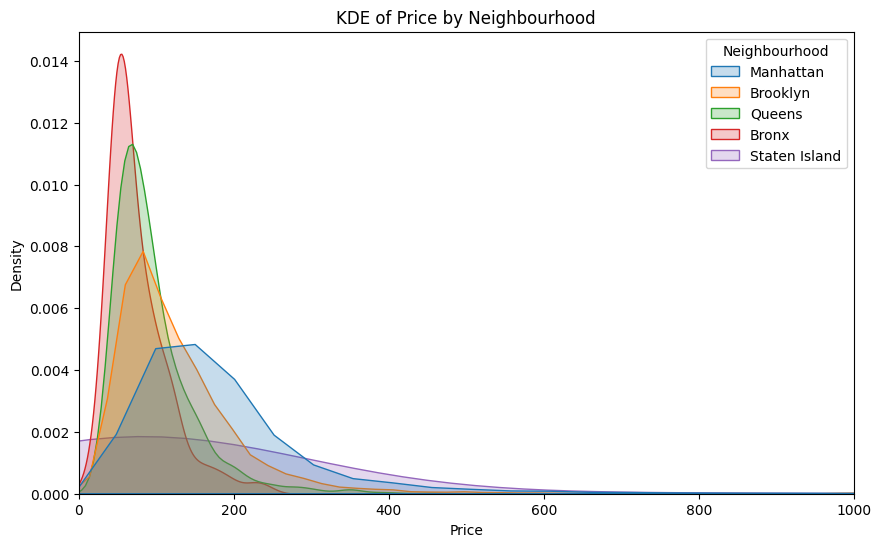

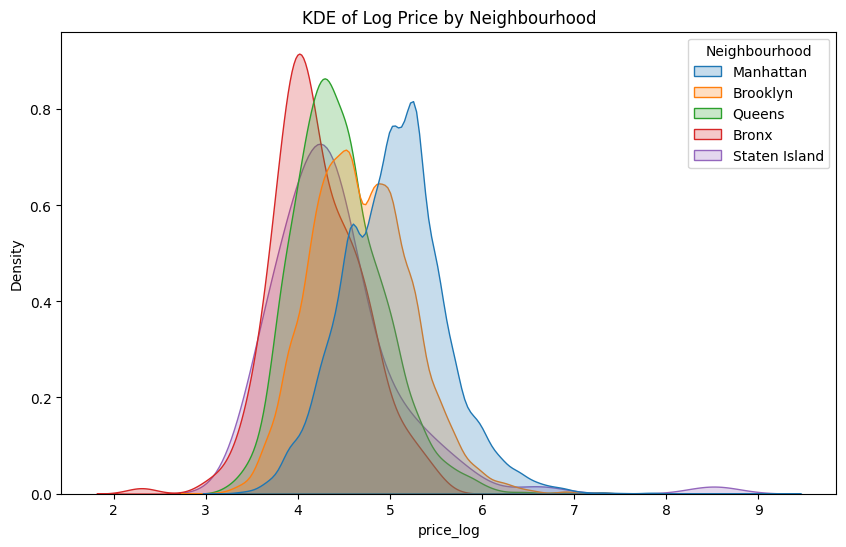


Q2.2 Coefficients (No Intercept)
Neighbourhood_Bronx: 75.28
Neighbourhood_Brooklyn: 127.75
Neighbourhood_Manhattan: 183.66
Neighbourhood_Queens: 96.86
Neighbourhood_Staten Island: 146.17

Q2.3 Coefficients (With Intercept)
Intercept: 75.28
Neighbourhood_Brooklyn: 52.47
Neighbourhood_Manhattan: 108.39
Neighbourhood_Queens: 21.58
Neighbourhood_Staten Island: 70.89

Q2.4 Model Evaluation
R-squared: 0.0459
RMSE: 140.92
Review Scores Rating Coefficient: 1.2119

Q2.5 Model Evaluation
R-squared: 0.0542
RMSE: 140.30
Review Scores Rating Coefficient: 1.2010


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load the dataset
df = pd.read_csv("/Users/hanimoudarres/Downloads/Foundations of ML/linear_models/assignment/data/Q1_clean.csv")
# Rename column to remove the trailing space for cleaner code
df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True)

# Q2.1: Averages by Neighbourhood
avg_stats = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Q2.1 Averages by Neighbourhood")
print(avg_stats)

# Create log price variable
df['price_log'] = np.log(df['Price'])

# Plot KDE of Price
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False, fill=True)
plt.title('KDE of Price by Neighbourhood')
plt.xlim(0, 1000) # Trimmed x-axis for better visibility of the distributions
plt.show()

# Plot KDE of Log Price
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price_log', hue='Neighbourhood', common_norm=False, fill=True)
plt.title('KDE of Log Price by Neighbourhood')
plt.show()

# Q2.2: Regression Without Intercept
X_no_int = pd.get_dummies(df[['Neighbourhood']], drop_first=False)
y = df['Price']

model_no_int = LinearRegression(fit_intercept=False)
model_no_int.fit(X_no_int, y)

print("\nQ2.2 Coefficients (No Intercept)")
for col, coef in zip(X_no_int.columns, model_no_int.coef_):
    print(f"{col}: {coef:.2f}")

# Q2.3: Regression With Intercept
# drop_first=True handles the dummy variable trap
X_int = pd.get_dummies(df[['Neighbourhood']], drop_first=True)
model_int = LinearRegression(fit_intercept=True)
model_int.fit(X_int, y)

print("\nQ2.3 Coefficients (With Intercept)")
print(f"Intercept: {model_int.intercept_:.2f}")
for col, coef in zip(X_int.columns, model_int.coef_):
    print(f"{col}: {coef:.2f}")

# Q2.4: Train/Test Split (Review Scores & Neighbourhood)
X4 = pd.get_dummies(df[['Neighbourhood']], drop_first=True)
X4['Review Scores Rating'] = df['Review Scores Rating']
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size=0.2, random_state=42)

mod4 = LinearRegression(fit_intercept=True)
mod4.fit(X4_train, y4_train)
y4_pred = mod4.predict(X4_test)

print("\nQ2.4 Model Evaluation")
print(f"R-squared: {r2_score(y4_test, y4_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y4_test, y4_pred)):.2f}")
idx_rev4 = list(X4.columns).index('Review Scores Rating')
print(f"Review Scores Rating Coefficient: {mod4.coef_[idx_rev4]:.4f}")

# Q2.5: Train/Test Split (Review Scores, Neighbourhood & Property Type)
X5 = pd.get_dummies(df[['Neighbourhood', 'Property Type']], drop_first=True)
X5['Review Scores Rating'] = df['Review Scores Rating']
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y, test_size=0.2, random_state=42)

mod5 = LinearRegression(fit_intercept=True)
mod5.fit(X5_train, y5_train)
y5_pred = mod5.predict(X5_test)

print("\nQ2.5 Model Evaluation")
print(f"R-squared: {r2_score(y5_test, y5_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y5_test, y5_pred)):.2f}")
idx_rev5 = list(X5.columns).index('Review Scores Rating')
print(f"Review Scores Rating Coefficient: {mod5.coef_[idx_rev5]:.4f}")

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  <br><br>
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  <br><br>
  In general, car prices in this dataset are right-skewed, clustering heavily in the lower-to-middle range with a long tail of more expensive cars. The overall mean price is $676,880 with a median of $647,000, and prices range from a minimum of $188,000 to a maximum of $1,465,000. When examining the grouped summary, the most expensive car brands on average are Kia ($1,369,000) and Jeep ($1,290,000), though these only have 1 observation each in the cleaned data. Among brands with a substantial number of observations, Mahindra ($1,100,167), Toyota ($800,340), and Honda ($788,722) are the most expensive.
  <br><br>
  3. Split the data into an 80% training set and a 20% testing set.
  <br><br>
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test 
  set? Does the joint model perform better or worse, and by home much?
  <br><br>
  The numeric-only model achieved a Test $R^2$ of 0.4477 and a Test RMSE of 198,590.63, while the categorical-only model performed slightly worse with a Test $R^2$ of 0.4265 and a Test RMSE of 202,363.33. The combined model performs significantly better than either individual model, achieving a Test $R^2$ of 0.7358 and a Test RMSE of 137,354.81. By combining the features, the joint model captures both wear-and-tear (mileage, age) and baseline prestige (brand, body type). It improves the Test $R^2$ by roughly 0.29 (a massive leap in explained variance) and reduces the error (RMSE) by approximately $61,000 to $65,000 compared to the isolated models.
  <br><br>
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  <br><br>
  As the degree of the polynomial expansion increases, the model performance slightly improves before suffering a massive drop due to overfitting. The Test $R^2$ peaks at Degree 3 with a value of 0.7494 (RMSE: 133,772.12). After Degree 3, the Test $R^2$ plummets drastically, dropping to 0.5388 at Degree 4 and 0.4807 at Degree 5. While it does not explicitly dip into negative numbers within the first 5 degrees for this specific subset, the rapid deterioration indicates severe overfitting. The best expanded model (Degree 3) provides a slight improvement over the best model from Part 4, increasing the $R^2$ by 0.0136 and decreasing the RMSE by about $3,582.
  <br><br>
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.
  <br><br>
  When plotting the predicted values against the true values for our best model (Degree 3), the points roughly line up along the diagonal, meaning our model's predictions track well with actual prices. However, there is noticeable "fanning" or spread at higher prices, indicating heteroskedasticity (the model loses precision on very expensive cars). The kernel density plot of the residuals is nicely bell-shaped and centered around exactly zero, showing that our errors are normally distributed and there is no systematic bias in our predictions. Overall, the model's strength is its solid accuracy on standard, mid-range cars (~75% variance explained), while its main weakness is its inability to precisely price high-end outliers.


--- Price Summary ---
count    9.220000e+02
mean     6.768807e+05
std      2.563079e+05
min      1.880000e+05
25%      4.642500e+05
50%      6.470000e+05
75%      8.367500e+05
max      1.465000e+06
Name: Price, dtype: float64


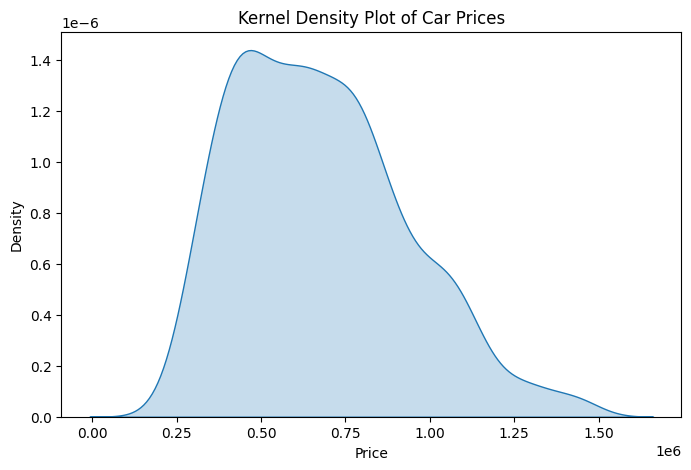


--- Price Summary by Make ---
               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           72.0  7.887222e+05  253474.460320   316000.0   580750.0   
Hyundai        304.0  6.884375e+05  273012.825123   248000.0   484750.0   
Jeep             1.0  1.290000e+06            NaN  1290000.0  1290000.0   
Kia              1.0  1.369000e+06            NaN  1369000.0  1369000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.625735e+05  214827.338943   287000.0   475000

/var/folders/vd/x0_2r16569l8hs6xlnlzd6900000gn/T/ipykernel_42472/523717498.py:52: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Price', hue='Make', common_norm=False, fill=True)


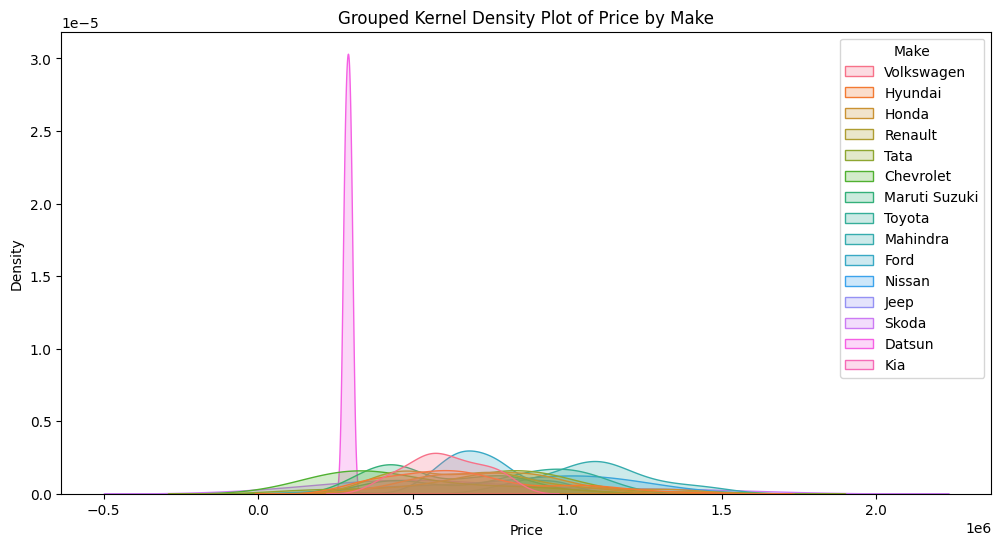


[Numeric Variables Only]
Train R^2: 0.4832 | Train RMSE: 181900.95
Test R^2:  0.4477 | Test RMSE:  198590.63

[Categorical Variables Only]
Train R^2: 0.5534 | Train RMSE: 169099.79
Test R^2:  0.4265 | Test RMSE:  202363.33

[Combined Model]
Train R^2: 0.7613 | Train RMSE: 123630.62
Test R^2:  0.7358 | Test RMSE:  137354.81

--- Polynomial Features Expansion ---
Degree 1 -> Test R^2: 0.7358 | Test RMSE: 137354.81
Degree 2 -> Test R^2: 0.7380 | Test RMSE: 136782.78
Degree 3 -> Test R^2: 0.5056 | Test RMSE: 187891.51
Degree 4 -> Test R^2: 0.4978 | Test RMSE: 189369.74
Degree 5 -> Test R^2: 0.4834 | Test RMSE: 192061.88

Best model achieved at Polynomial Degree 2


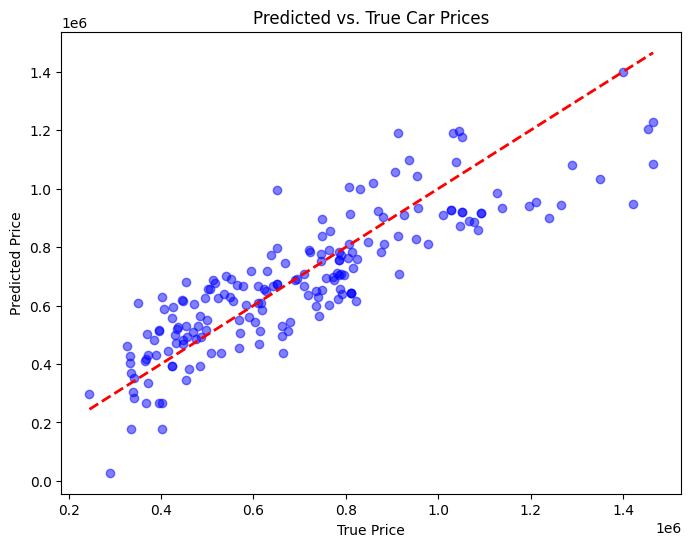

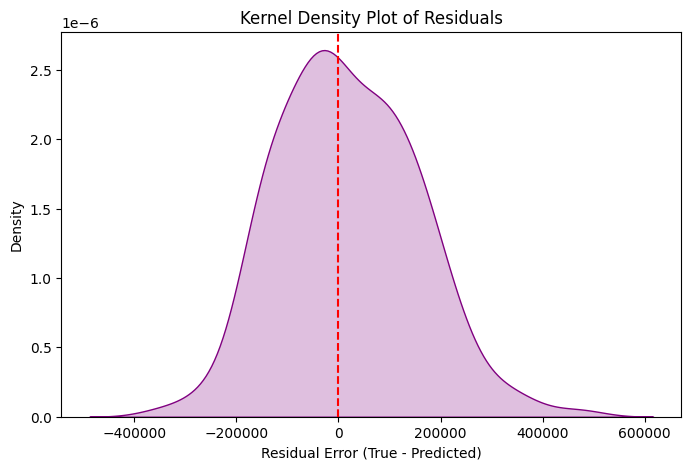

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Part 1: Load and Clean the Data
file_path = "/Users/hanimoudarres/Downloads/Foundations of ML/linear_models/assignment/data/cars_hw.csv"
df = pd.read_csv(file_path)

# Drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
elif df.columns[0] == '""' or 'Unnamed' in df.columns[0]:
    df = df.drop(df.columns[0], axis=1)

# Extract numeric values from string columns
df['Transmission'] = df['Transmission'].str.extract(r'(\d+)').astype(float)
df['No_of_Owners'] = df['No_of_Owners'].str.extract(r'(\d+)').astype(float)

# Fill any resulting NaNs with the median
df['Transmission'] = df['Transmission'].fillna(df['Transmission'].median())
df['No_of_Owners'] = df['No_of_Owners'].fillna(df['No_of_Owners'].median())

# Remove outliers using the IQR method for better linear modeling
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5 * IQR) & (data[col] <= Q3 + 1.5 * IQR)]

df = remove_outliers(df, 'Price')
df = remove_outliers(df, 'Mileage_Run')

# Part 2: Summarize and Plot Price
print("--- Price Summary ---")
print(df['Price'].describe())

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Price', fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.xlabel('Price')
plt.show()

print("\n--- Price Summary by Make ---")
print(df.groupby('Make')['Price'].describe())

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Price', hue='Make', common_norm=False, fill=True)
plt.title('Grouped Kernel Density Plot of Price by Make')
plt.xlabel('Price')
plt.show()

# Part 3: Train-Test Split
X = df.drop(columns=['Price'])
y = df['Price']

# Identify numeric and categorical columns
num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']
cat_cols = ['Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'Make']

# Part 4: Regressions (Numeric, Categorical, Combined)
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    
    r2_tr = r2_score(y_tr, y_pred_tr)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    
    r2_te = r2_score(y_te, y_pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, y_pred_te))
    
    print(f"\n[{model_name}]")
    print(f"Train R^2: {r2_tr:.4f} | Train RMSE: {rmse_tr:.2f}")
    print(f"Test R^2:  {r2_te:.4f} | Test RMSE:  {rmse_te:.2f}")
    return r2_te, rmse_te

# 1. Numeric Only
X_num = X[num_cols]
X_train_num, X_test_num, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)
evaluate_model(LinearRegression(), X_train_num, y_train, X_test_num, y_test, "Numeric Variables Only")

# 2. Categorical Only (One-Hot Encoded)
X_cat = pd.get_dummies(X[cat_cols], drop_first=True) # drop_first avoids dummy trap
X_train_cat, X_test_cat = train_test_split(X_cat, test_size=0.2, random_state=42)
evaluate_model(LinearRegression(), X_train_cat, y_train, X_test_cat, y_test, "Categorical Variables Only")

# 3. Combined Model
X_comb = pd.concat([X_num, X_cat], axis=1)
X_train_comb, X_test_comb = train_test_split(X_comb, test_size=0.2, random_state=42)
evaluate_model(LinearRegression(), X_train_comb, y_train, X_test_comb, y_test, "Combined Model")

# Part 5: Polynomial Features
print("\n--- Polynomial Features Expansion ---")
best_degree = 1
best_r2 = -float('inf')

# We check degrees 1 through 5
for degree in range(1, 6): 
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_num_poly = poly.fit_transform(X_num)
    X_num_poly_df = pd.DataFrame(X_num_poly, index=X.index)
    
    # Combine polynomial numeric features with original categorical features
    X_poly_comb = pd.concat([X_num_poly_df, X_cat], axis=1)
    X_poly_comb.columns = X_poly_comb.columns.astype(str) # Fix column names for sklearn
    
    X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly_comb, y, test_size=0.2, random_state=42)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train_poly)
    y_pred_te = lr_poly.predict(X_test_poly)
    
    r2_te = r2_score(y_test_poly, y_pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_test_poly, y_pred_te))
    
    print(f"Degree {degree} -> Test R^2: {r2_te:.4f} | Test RMSE: {rmse_te:.2f}")
    
    if r2_te > best_r2:
        best_r2 = r2_te
        best_degree = degree

print(f"\nBest model achieved at Polynomial Degree {best_degree}")

# Part 6: Best Model Evaluation (Residuals & Plot)

# Re-running the best degree to get predictions
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_num_poly_best = pd.DataFrame(poly_best.fit_transform(X_num), index=X.index)
X_poly_comb_best = pd.concat([X_num_poly_best, X_cat], axis=1)
X_poly_comb_best.columns = X_poly_comb_best.columns.astype(str)

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_poly_comb_best, y, test_size=0.2, random_state=42)
best_model = LinearRegression()
best_model.fit(X_train_best, y_train_best)
y_pred_final = best_model.predict(X_test_best)

# 1. True vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_best, y_pred_final, alpha=0.5, color='blue')
# Draw the diagonal line where True == Predicted
plt.plot([y_test_best.min(), y_test_best.max()], [y_test_best.min(), y_test_best.max()], 'r--', lw=2)
plt.title('Predicted vs. True Car Prices')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.show()

# 2. Residuals KDE Plot
residuals = y_test_best - y_pred_final
plt.figure(figsize=(8, 5))
sns.kdeplot(residuals, fill=True, color='purple')
plt.title('Kernel Density Plot of Residuals')
plt.xlabel('Residual Error (True - Predicted)')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.
<br><br><br>

### Answers written on paper on attached images
